# APN Dataset EDA Report: MIMIC_III

本报告用于深入理解该数据集在 APN 项目中的形态、含义与时序特性。

- 覆盖内容：数据来源、样本规模、不规则采样特性、缺失模式、变量相关性、典型时序轨迹
- 注意：首次运行可能触发自动下载或预处理（取决于数据集）


## 数据集背景

MIMIC-III 是 ICU 电子病历数据库。
APN 使用的是 DeBrouwer2019 预处理版本（96 个连续变量，时间离散后再形成不规则观测）。
注意：该版本需要你先具备受控访问并准备 complete_tensor.csv。


In [1]:
import os
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
if (PROJECT_ROOT / 'reports').exists() and str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from reports.irregular_eda_utils import (
    compute_dataset_summary,
    get_sample_lengths,
    plot_channel_correlation,
    plot_channel_missingness,
    plot_interarrival_distribution,
    plot_multichannel_trajectories,
    plot_sample_length_distributions,
    to_long_frame,
 )

def configure_matplotlib_cjk_font() -> str:
    candidate_font_paths = [
        '/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc',
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc',
    ]
    registered_names = []
    for font_path in candidate_font_paths:
        if os.path.exists(font_path):
            fm.fontManager.addfont(font_path)
            registered_names.append(fm.FontProperties(fname=font_path).get_name())

    preferred_fonts = registered_names + [
        'WenQuanYi Zen Hei',
        'Noto Sans CJK SC',
        'Source Han Sans SC',
        'Microsoft YaHei',
        'SimHei',
        'Arial Unicode MS',
    ]
    available_fonts = {font.name for font in fm.fontManager.ttflist}
    for font_name in preferred_fonts:
        if font_name in available_fonts:
            mpl.rcParams['font.family'] = 'sans-serif'
            mpl.rcParams['font.sans-serif'] = [font_name, 'DejaVu Sans']
            mpl.rcParams['axes.unicode_minus'] = False
            return font_name

    mpl.rcParams['font.family'] = 'sans-serif'
    mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']
    mpl.rcParams['axes.unicode_minus'] = False
    return 'DejaVu Sans'

sns.set_theme(style='whitegrid', context='talk')
selected_cjk_font = configure_matplotlib_cjk_font()
print(f'Matplotlib CJK font: {selected_cjk_font}')
np.random.seed(0)


Matplotlib CJK font: WenQuanYi Zen Hei


## 1) 加载数据并统一结构

将不同数据集统一为 records = [{t, x}] 形式：
- t: 一维时间戳数组
- x: 二维观测矩阵 [time, channel]


In [2]:
from data.dependencies.tsdm.tasks.mimic_iii_debrouwer2019 import MIMIC_III_DeBrouwer2019
from reports.irregular_eda_utils import records_from_task_dataset

dataset_name = 'MIMIC_III'
time_unit = 'normalized time (0-1)'

task = MIMIC_III_DeBrouwer2019(seq_len=72 - 0.5, pred_len=3, value_norm='none')
all_ds = task.get_dataset((0, 'train'))
records = records_from_task_dataset(all_ds)
channel_names = [str(c) for c in task.dataset.columns.tolist()]
print(f'Loaded {len(records)} samples from fold-0 train split.')
print('Hint: MIMIC full report requires ~/.tsdm/rawdata/MIMIC_III_DeBrouwer2019/complete_tensor.csv')


/home/yixin/study/imts/APN/data/dependencies/tsdm/utils/remote.py:15: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/home/yixin/study/imts/APN/data/dependencies/tsdm/datasets/base.py:308: UserWarning: File 'timeseries.parquet' failed to validate!File hash '414a29be16a76c630810af2ca2ad5f2fef89ff93c7e27e68ef4d670da1276b22' does not match reference '2ebb7da820560f420f71c0b6fb068a46449ef89b238e97ba81659220fae8151b'.𝗜𝗴𝗻𝗼𝗿𝗲 𝘁𝗵𝗶𝘀 𝘄𝗮𝗿𝗻𝗶𝗻𝗴 𝗶𝗳 𝘁𝗵𝗲 𝗳𝗶𝗹𝗲 𝗳𝗼𝗿𝗺𝗮𝘁 𝗶𝘀 𝗽𝗮𝗿𝗾𝘂𝗲𝘁.
  warnings.warn(
/home/yixin/study/imts/APN/data/dependencies/tsdm/datasets/base.py:308: UserWarning: File 'metadata.parquet' failed to validate!File hash '081d8f931212ab6072e7b541e924cc61e1235644303c4553ec98bc07af13f514' does not match reference '4779aa3639f468126ea263645510d5395d85b73caf1c7abb0a486561b761f5b4'.𝗜𝗴𝗻𝗼𝗿𝗲 𝘁𝗵𝗶𝘀 𝘄𝗮𝗿𝗻𝗶𝗻𝗴 𝗶𝗳 𝘁𝗵𝗲 𝗳𝗶𝗹𝗲 𝗳𝗼𝗿𝗺𝗮𝘁 𝗶𝘀 𝗽𝗮𝗿𝗾𝘂𝗲𝘁.
  warnings.warn(


Loaded 18158 samples from fold-0 train split.
Hint: MIMIC full report requires ~/.tsdm/rawdata/MIMIC_III_DeBrouwer2019/complete_tensor.csv


In [3]:
summary = compute_dataset_summary(records, channel_names)
lens = get_sample_lengths(records)
summary


n_samples              18158.000000
n_channels                96.000000
mean_timestamps            4.280703
median_timestamps          4.000000
mean_observations         39.679645
median_observations       37.000000
mean_duration              0.314147
dtype: float64

## 2) 样本级统计

观察每个样本时间点数量、总观测数量、时长分布。

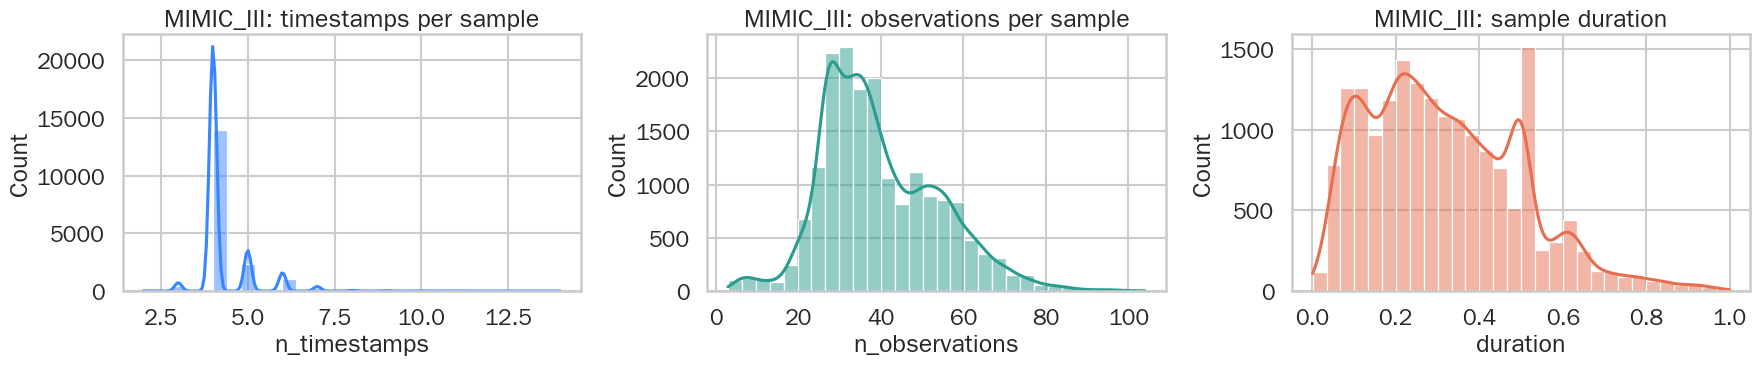

In [4]:
plot_sample_length_distributions(lens, title_prefix=f'{dataset_name}: ')

## 3) 生成长表并查看总体观测规模

In [5]:
import os

n_jobs = min(8, os.cpu_count() or 1)
long_df = to_long_frame(records, channel_names, n_jobs=n_jobs)
print(f'Using n_jobs={n_jobs}')
print('long_df shape:', long_df.shape)
long_df.head()


Using n_jobs=8
long_df shape: (720503, 4)


,sample_id,time,channel,value
0,0,0.000000,38,3.0
1,0,0.283084,10,138.0
2,0,0.283084,11,82.0
3,0,0.283084,12,0.0
4,0,0.283084,13,0.3


## 4) 缺失与稀疏模式（样本 x 通道）

热图显示 log(1 + 观测次数)，越亮表示该通道在该样本中记录越密集。

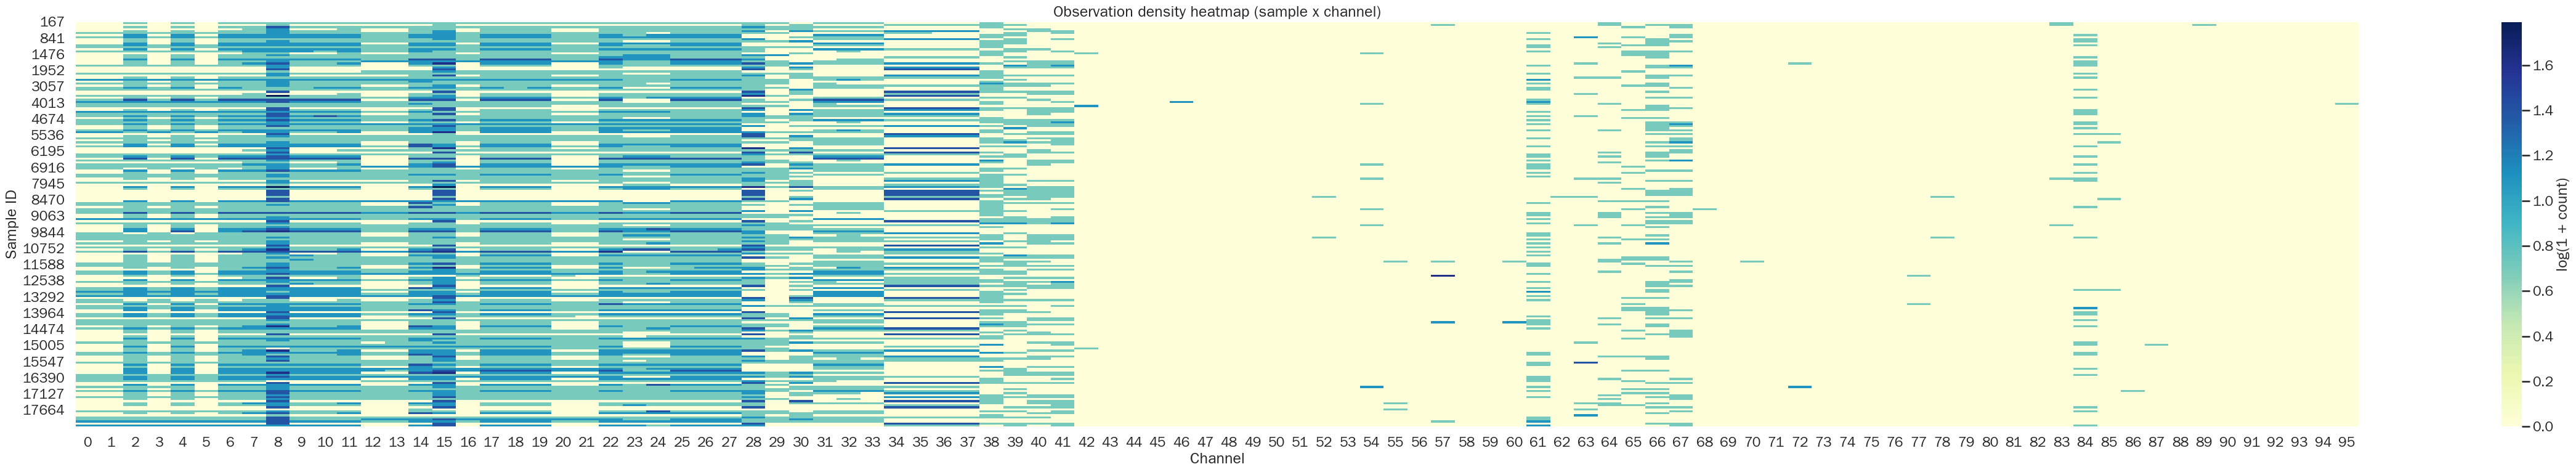

In [6]:
plot_channel_missingness(long_df, channel_names, n_samples=200)

## 5) 采样间隔分布

衡量不规则性：如果分布非常分散，说明采样时间并不均匀。

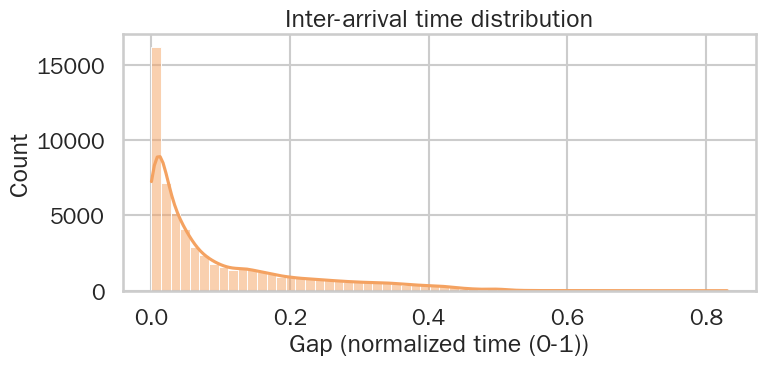

In [7]:
plot_interarrival_distribution(records, time_unit=time_unit)

## 6) 多变量时序轨迹（随机样本）

显示若干关键通道的多样本轨迹叠加。

In [8]:
top_channels = long_df['channel'].value_counts().head(4).index.tolist()
channels_to_plot = top_channels if len(top_channels) >= 2 else channel_names[:4]
channels_to_plot


['8', '15', '28', '14']

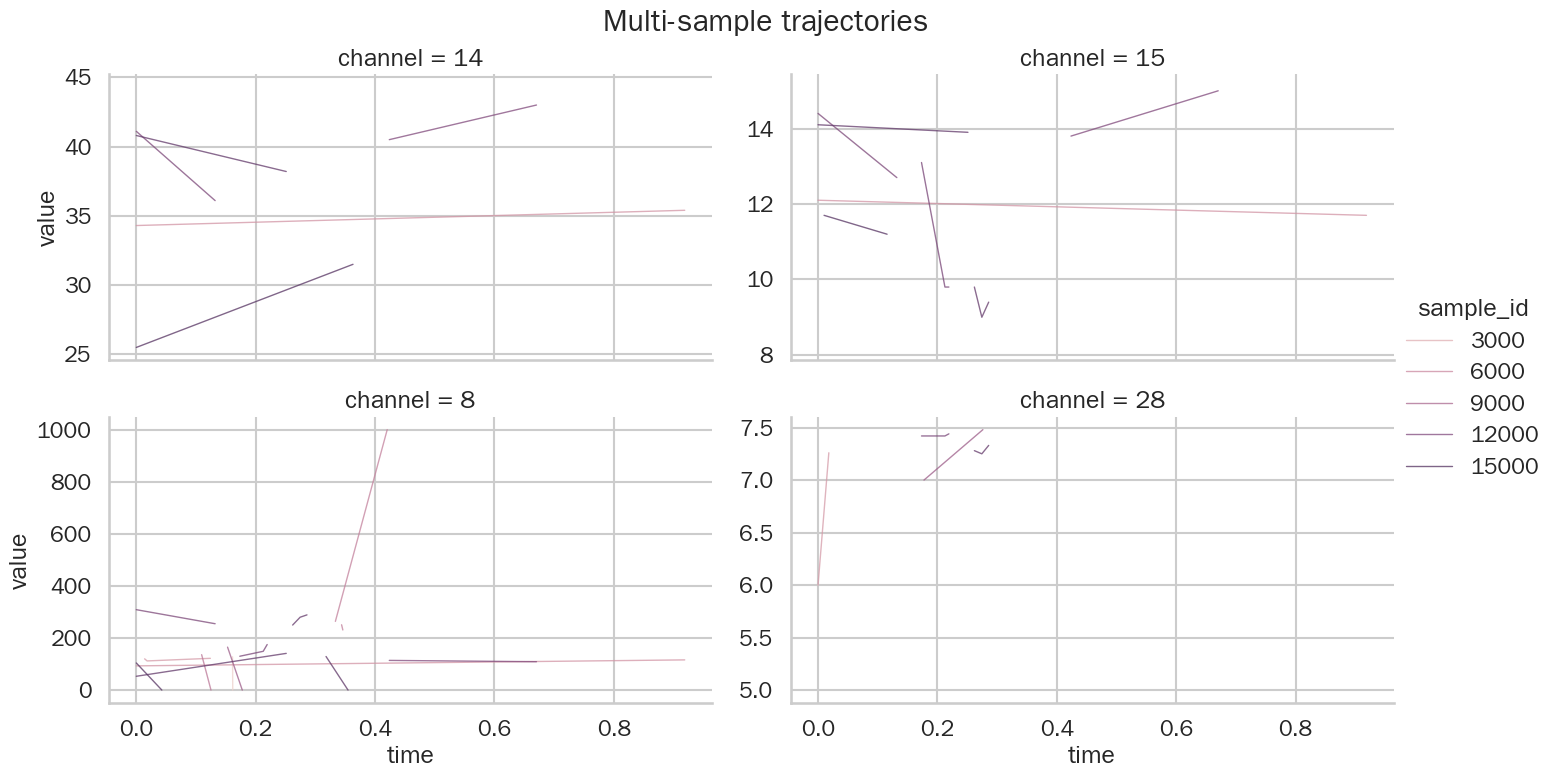

In [9]:
plot_multichannel_trajectories(long_df, channels=channels_to_plot, n_samples=16)

## 7) 通道相关性

基于“每个样本每个通道的均值”估计变量之间的相关结构。

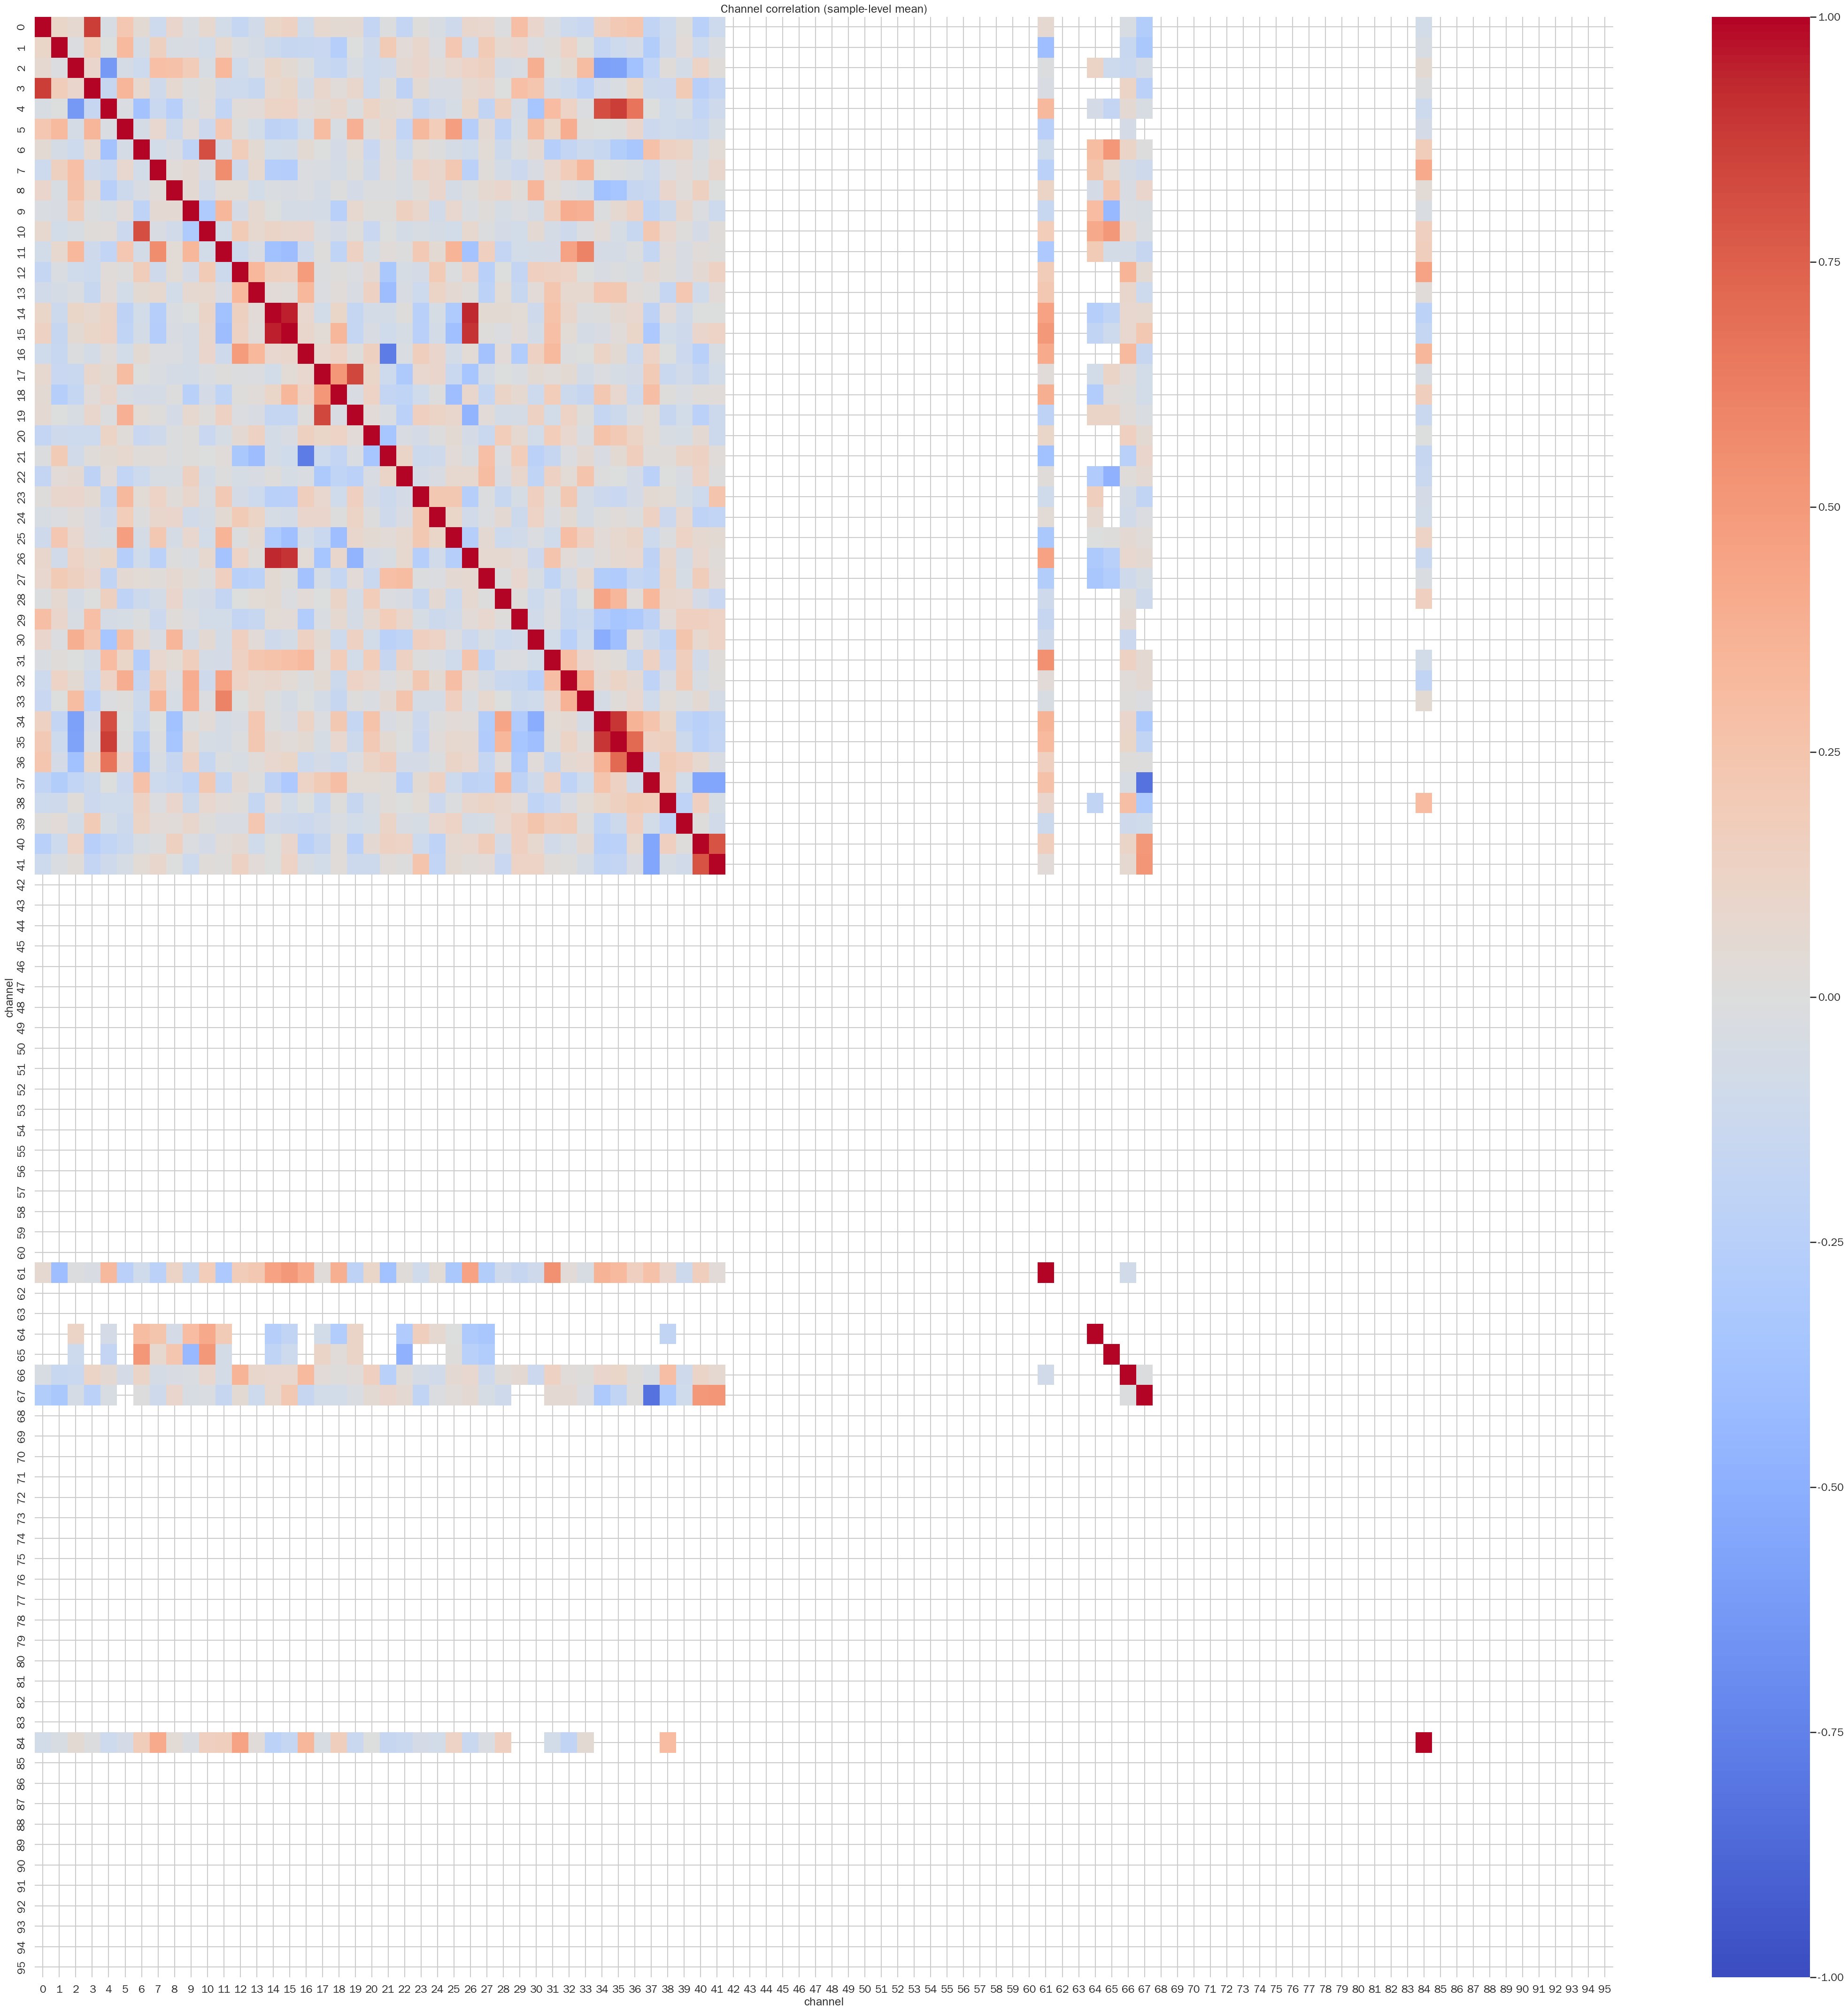

In [10]:
plot_channel_correlation(long_df, channel_names, max_samples=300)

## 8) 通道覆盖率与缺失机制（Step 1）

从三个层面看缺失：
1. 样本-通道层：每个样本覆盖了多少通道
2. 通道-样本层：每个通道在多少样本里出现
3. 时间窗层：不同时间窗内各通道出现概率

In [11]:
import matplotlib.ticker as mtick

# 1) 样本-通道覆盖率
sample_channel_present = (
    long_df.groupby(['sample_id', 'channel']).size().gt(0).rename('present').reset_index()
)

sample_coverage = (
    sample_channel_present.groupby('sample_id')['present'].mean().rename('sample_channel_coverage')
)

# 2) 通道-样本覆盖率
channel_coverage = (
    sample_channel_present.groupby('channel')['present'].mean().sort_values(ascending=False)
)

print('样本数:', long_df['sample_id'].nunique())
print('通道数:', len(channel_names))
print('样本平均通道覆盖率:', round(sample_coverage.mean(), 4))
print('样本通道覆盖率中位数:', round(sample_coverage.median(), 4))
print('\n覆盖率最低的 10 个通道:')
print(channel_coverage.tail(10))
print('\n覆盖率最高的 10 个通道:')
print(channel_coverage.head(10))

样本数: 18158
通道数: 96
样本平均通道覆盖率: 1.0
样本通道覆盖率中位数: 1.0

覆盖率最低的 10 个通道:
channel
87    1.0
88    1.0
89    1.0
9     1.0
90    1.0
91    1.0
92    1.0
93    1.0
94    1.0
95    1.0
Name: present, dtype: float64

覆盖率最高的 10 个通道:
channel
0     1.0
1     1.0
10    1.0
11    1.0
12    1.0
13    1.0
14    1.0
15    1.0
16    1.0
17    1.0
Name: present, dtype: float64


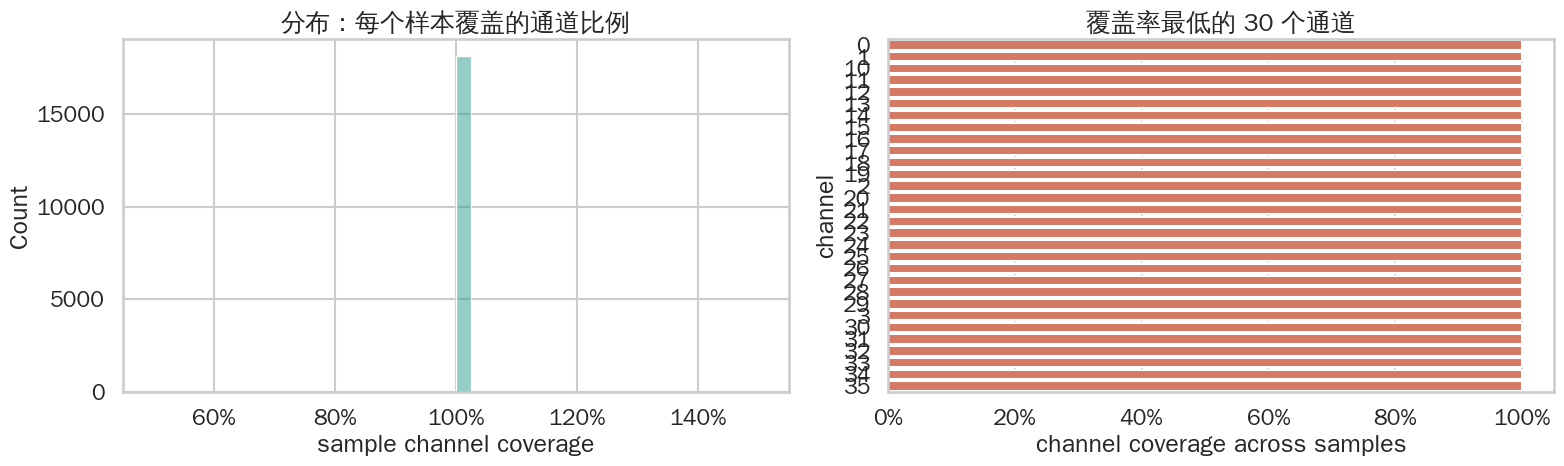

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(sample_coverage, bins=40, kde=True, ax=axes[0], color='#2a9d8f')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title('分布：每个样本覆盖的通道比例')
axes[0].set_xlabel('sample channel coverage')

channel_coverage_sorted = channel_coverage.sort_values()
plot_n = min(30, len(channel_coverage_sorted))
channel_tail = channel_coverage_sorted.head(plot_n)
sns.barplot(x=channel_tail.values, y=channel_tail.index, ax=axes[1], color='#e76f51')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title(f'覆盖率最低的 {plot_n} 个通道')
axes[1].set_xlabel('channel coverage across samples')
axes[1].set_ylabel('channel')

plt.tight_layout()

按时间窗聚合的平均出现率:
time_bin
0     1.0
1     1.0
2     1.0
3     1.0
4     1.0
5     1.0
6     1.0
7     1.0
8     1.0
9     1.0
10    1.0
11    1.0
Name: mean_presence_rate, dtype: float64


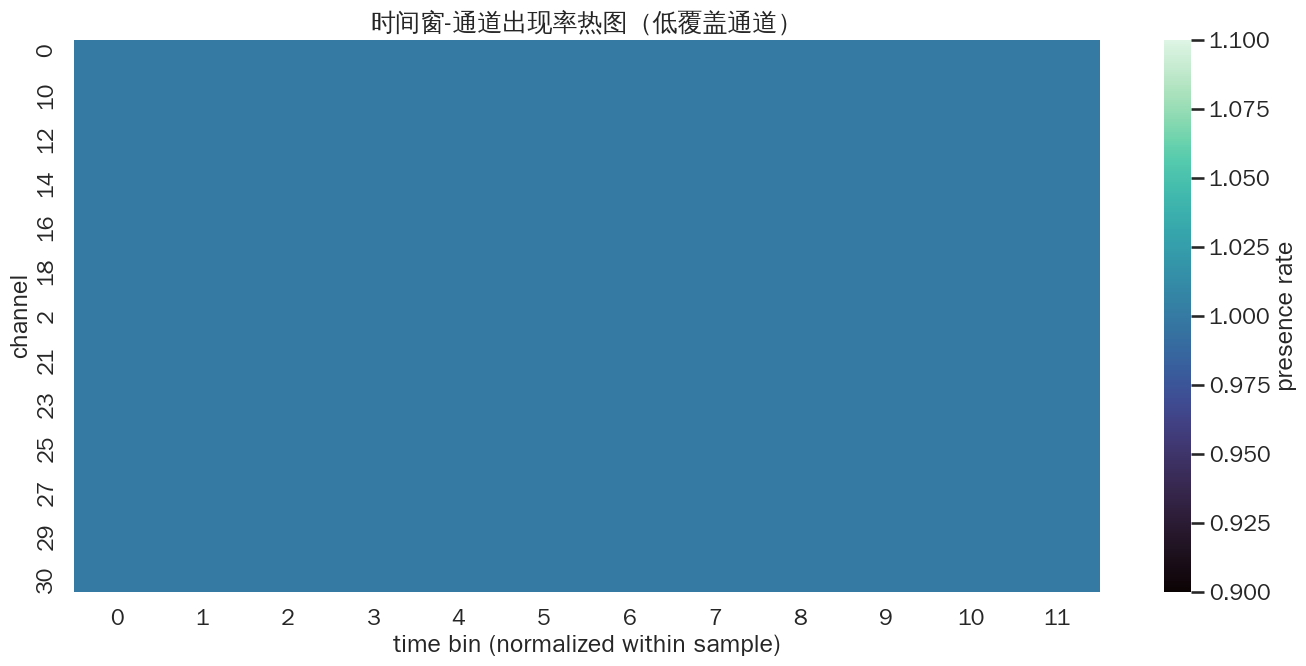

In [13]:
n_bins = 12
work_df = long_df[['sample_id', 'time', 'channel']].copy()

# 归一化时间，避免不同样本尺度差异
sample_tmin = work_df.groupby('sample_id')['time'].transform('min')
sample_tmax = work_df.groupby('sample_id')['time'].transform('max')
denom = (sample_tmax - sample_tmin).replace(0, np.nan)
work_df['time_norm'] = ((work_df['time'] - sample_tmin) / denom).fillna(0.0)

work_df['time_bin'] = np.clip((work_df['time_norm'] * n_bins).astype(int), 0, n_bins - 1)

# 每个 (sample, bin, channel) 是否出现
sbc_present = (
    work_df.groupby(['sample_id', 'time_bin', 'channel']).size().gt(0).rename('present').reset_index()
)

bin_channel_presence = (
    sbc_present.groupby(['time_bin', 'channel'])['present'].mean().unstack(fill_value=0.0)
)

# 选覆盖率最低的通道做热图，更容易看到缺失机制
low_cov_channels = channel_coverage.sort_values().head(min(25, len(channel_coverage))).index.tolist()
heat_df = bin_channel_presence.reindex(columns=low_cov_channels, fill_value=0.0)

plt.figure(figsize=(14, 7))
sns.heatmap(heat_df.T, cmap='mako', cbar_kws={'label': 'presence rate'})
plt.title('时间窗-通道出现率热图（低覆盖通道）')
plt.xlabel('time bin (normalized within sample)')
plt.ylabel('channel')
plt.tight_layout()

bin_summary = (
    sbc_present.groupby('time_bin')['present'].mean().rename('mean_presence_rate')
)
print('按时间窗聚合的平均出现率:')
print(bin_summary)

## 10) 观测间隔 Δt 结构（Step 2）

分别统计：
1. 全局 Δt 分布
2. 分通道 Δt（在样本内按该通道观测时间排序）
3. 分样本 Δt（样本内相邻观测时间）

In [14]:
# 全局与分样本 Δt（按 sample 内时间去重后排序）
sample_dt_records = []
for sid, g in long_df[['sample_id', 'time']].drop_duplicates().groupby('sample_id'):
    t_sorted = np.sort(g['time'].to_numpy())
    if len(t_sorted) > 1:
        dt = np.diff(t_sorted)
        dt = dt[np.isfinite(dt) & (dt >= 0)]
        if len(dt) > 0:
            sample_dt_records.append(pd.DataFrame({'sample_id': sid, 'dt': dt}))

sample_dt_df = pd.concat(sample_dt_records, ignore_index=True) if sample_dt_records else pd.DataFrame(columns=['sample_id', 'dt'])

# 分通道 Δt：在样本内、按 channel 分组后计算
channel_dt_records = []
for (sid, ch), g in long_df[['sample_id', 'channel', 'time']].drop_duplicates().groupby(['sample_id', 'channel']):
    t_sorted = np.sort(g['time'].to_numpy())
    if len(t_sorted) > 1:
        dt = np.diff(t_sorted)
        dt = dt[np.isfinite(dt) & (dt >= 0)]
        if len(dt) > 0:
            channel_dt_records.append(pd.DataFrame({'sample_id': sid, 'channel': ch, 'dt': dt}))

channel_dt_df = pd.concat(channel_dt_records, ignore_index=True) if channel_dt_records else pd.DataFrame(columns=['sample_id', 'channel', 'dt'])

print('全局 Δt 条数:', len(sample_dt_df))
print('分通道 Δt 条数:', len(channel_dt_df))
print('全局 Δt 描述:')
print(sample_dt_df['dt'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

全局 Δt 条数: 59571
分通道 Δt 条数: 199460
全局 Δt 描述:
count    59571.000000
mean         0.095756
std          0.114513
min          0.000347
50%          0.045849
90%          0.277527
95%          0.352206
99%          0.453387
max          0.830844
Name: dt, dtype: float64


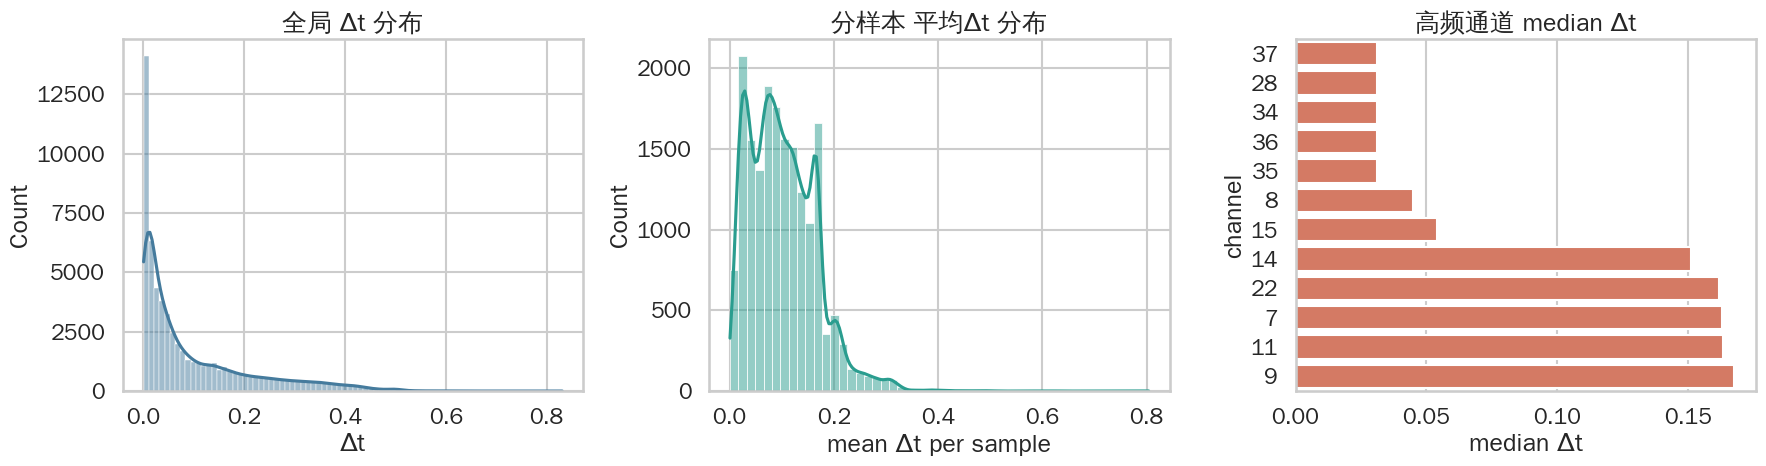

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if not sample_dt_df.empty:
    sns.histplot(sample_dt_df['dt'], bins=80, kde=True, ax=axes[0], color='#457b9d')
    axes[0].set_title('全局 Δt 分布')
    axes[0].set_xlabel('Δt')

    sample_dt_mean = sample_dt_df.groupby('sample_id')['dt'].mean()
    sns.histplot(sample_dt_mean, bins=50, kde=True, ax=axes[1], color='#2a9d8f')
    axes[1].set_title('分样本 平均Δt 分布')
    axes[1].set_xlabel('mean Δt per sample')

if not channel_dt_df.empty:
    top_dt_channels = channel_dt_df['channel'].value_counts().head(12).index
    channel_dt_top = channel_dt_df[channel_dt_df['channel'].isin(top_dt_channels)]
    channel_dt_summary = channel_dt_top.groupby('channel')['dt'].median().sort_values()
    sns.barplot(x=channel_dt_summary.values, y=channel_dt_summary.index, ax=axes[2], color='#e76f51')
    axes[2].set_title('高频通道 median Δt')
    axes[2].set_xlabel('median Δt')

plt.tight_layout()

## 11) 通道共现结构（Step 3）

将时间归一化后分桶，统计同一样本同一时间窗内通道的共现，并用 Jaccard 近似度观察结构。

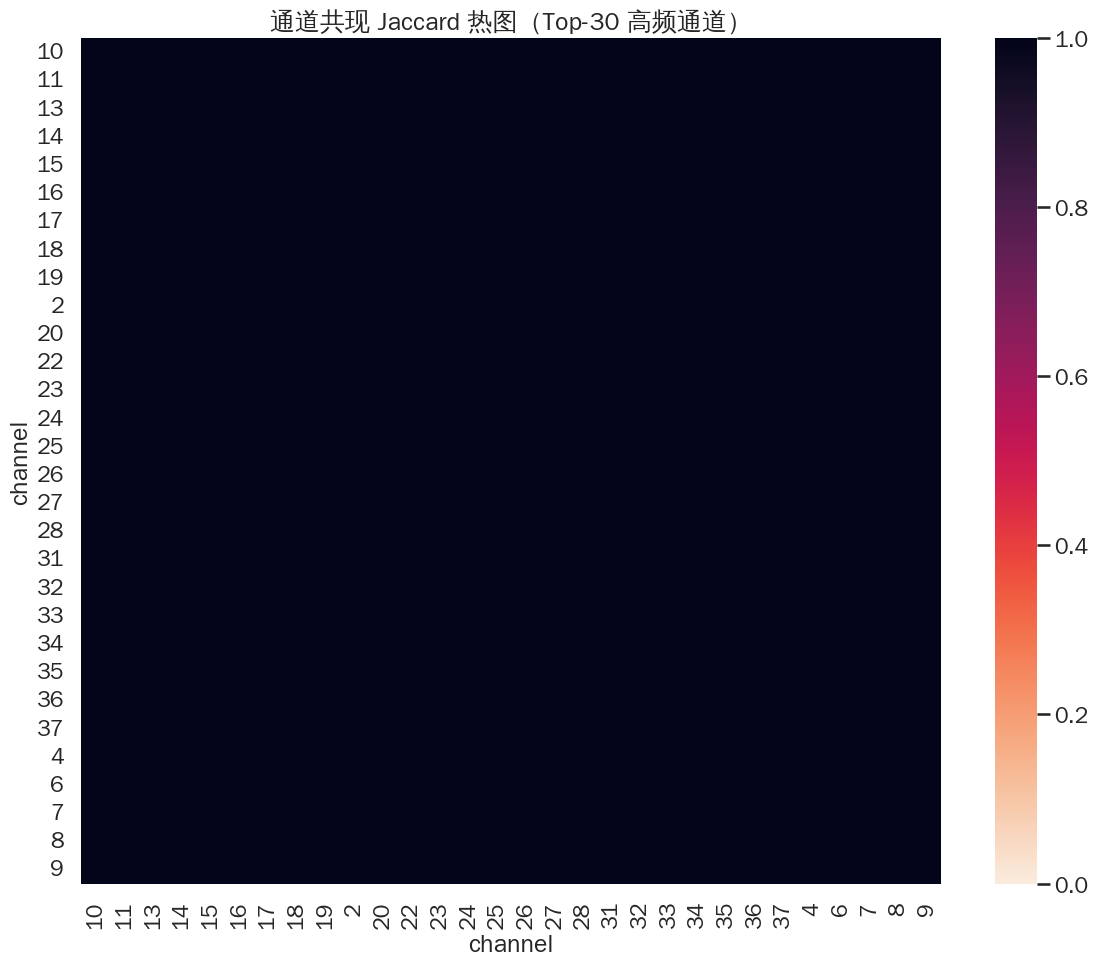

In [16]:
co_n_bins = 12
co_df = long_df[['sample_id', 'time', 'channel']].copy()

co_tmin = co_df.groupby('sample_id')['time'].transform('min')
co_tmax = co_df.groupby('sample_id')['time'].transform('max')
co_denom = (co_tmax - co_tmin).replace(0, np.nan)
co_df['time_norm'] = ((co_df['time'] - co_tmin) / co_denom).fillna(0.0)
co_df['time_bin'] = np.clip((co_df['time_norm'] * co_n_bins).astype(int), 0, co_n_bins - 1)

# 限制在高频通道，避免矩阵过大
top_co_channels = co_df['channel'].value_counts().head(30).index.tolist()
co_df = co_df[co_df['channel'].isin(top_co_channels)].drop_duplicates(['sample_id', 'time_bin', 'channel'])

event_key = co_df['sample_id'].astype(str) + '_' + co_df['time_bin'].astype(str)
presence_mat = pd.crosstab(event_key, co_df['channel']).astype(bool)

# 共现计数与 Jaccard
co_count = presence_mat.T.dot(presence_mat).astype(float)
diag = np.diag(co_count)
union = diag[:, None] + diag[None, :] - co_count.values
jaccard = np.divide(co_count.values, union, out=np.zeros_like(co_count.values), where=union > 0)
jaccard_df = pd.DataFrame(jaccard, index=co_count.index, columns=co_count.columns)

plt.figure(figsize=(12, 10))
sns.heatmap(jaccard_df, cmap='rocket_r', vmin=0, vmax=1)
plt.title('通道共现 Jaccard 热图（Top-30 高频通道）')
plt.tight_layout()

## 12) 目标分布与跨切分漂移（Step 4）

这里将 train/val/test 的输入与目标值分开统计，观察预测目标 y 的分布差异，以及按通道的均值漂移。

In [17]:
def split_values(task_obj, split_key):
    ds = task_obj.get_dataset((0, split_key))
    x_vals, y_vals = [], []
    for sample in ds:
        x = np.asarray(sample.inputs[1], dtype=float)
        y = np.asarray(sample.targets, dtype=float)
        x_vals.append(x[np.isfinite(x)])
        y_vals.append(y[np.isfinite(y)])
    x_flat = np.concatenate(x_vals) if x_vals else np.array([])
    y_flat = np.concatenate(y_vals) if y_vals else np.array([])
    return x_flat, y_flat

split_stats = {}
for split in ['train', 'val', 'test']:
    x_flat, y_flat = split_values(task, split)
    split_stats[split] = {
        'x_mean': float(np.mean(x_flat)) if len(x_flat) else np.nan,
        'x_std': float(np.std(x_flat)) if len(x_flat) else np.nan,
        'y_mean': float(np.mean(y_flat)) if len(y_flat) else np.nan,
        'y_std': float(np.std(y_flat)) if len(y_flat) else np.nan,
        'x_count': int(len(x_flat)),
        'y_count': int(len(y_flat)),
    }

pd.DataFrame(split_stats).T

,x_mean,x_std,y_mean,y_std,x_count,y_count
train,63.858152,208.246868,54.228567,162.917910,191763.0,528740.0
val,64.766915,169.849391,55.004962,140.000824,21028.0,58105.0
test,64.691470,195.015743,53.846068,133.102950,23366.0,64256.0


,split,x_smd_vs_train,y_smd_vs_train
0,val,0.004364,0.004766
1,test,0.004002,0.002348


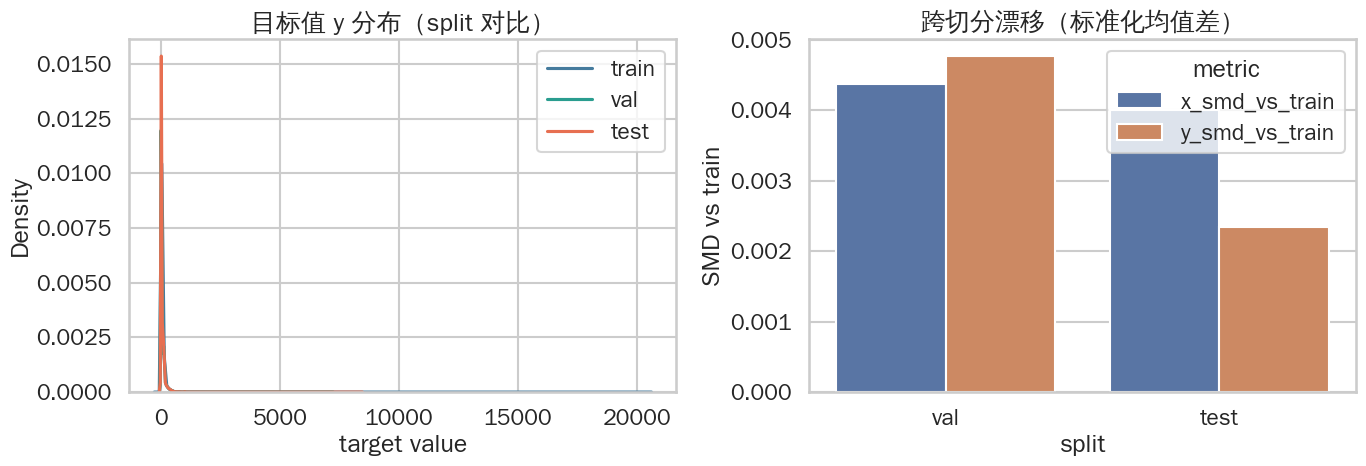

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for split, color in [('train', '#457b9d'), ('val', '#2a9d8f'), ('test', '#e76f51')]:
    _, y_flat = split_values(task, split)
    if len(y_flat):
        sns.kdeplot(y_flat, ax=axes[0], label=split, color=color, fill=False)

axes[0].set_title('目标值 y 分布（split 对比）')
axes[0].set_xlabel('target value')
axes[0].legend()

# 漂移度量：split 与 train 的标准化均值差
rows = []
train_x, train_y = split_values(task, 'train')
for split in ['val', 'test']:
    x_flat, y_flat = split_values(task, split)
    x_smd = abs(np.mean(x_flat) - np.mean(train_x)) / (np.std(train_x) + 1e-8)
    y_smd = abs(np.mean(y_flat) - np.mean(train_y)) / (np.std(train_y) + 1e-8)
    rows.append({'split': split, 'x_smd_vs_train': x_smd, 'y_smd_vs_train': y_smd})

drift_df = pd.DataFrame(rows)
drift_plot = drift_df.melt(id_vars='split', var_name='metric', value_name='value')
sns.barplot(data=drift_plot, x='split', y='value', hue='metric', ax=axes[1])
axes[1].set_title('跨切分漂移（标准化均值差）')
axes[1].set_ylabel('SMD vs train')

plt.tight_layout()
drift_df

## 13) 标准化策略影响（Step 5）

对比 value_norm = none / legacy_global / train_only 在同一 split 下的统计差异。

In [19]:
from data.dependencies.tsdm.tasks.mimic_iii_debrouwer2019 import MIMIC_III_DeBrouwer2019

def flat_values_by_norm(value_norm_mode, split='train'):
    t = MIMIC_III_DeBrouwer2019(seq_len=72 - 0.5, pred_len=3, value_norm=value_norm_mode)
    ts = t.dataset
    available_ids = pd.Index(ts.index.get_level_values(0).unique())
    requested_ids = pd.Index(t.folds[0][split])
    valid_ids = requested_ids.intersection(available_ids)
    missing_ids = requested_ids.difference(available_ids)

    if len(missing_ids):
        print(f'value_norm={value_norm_mode}, split={split}: skipped {len(missing_ids)} missing IDs')

    if len(valid_ids) == 0:
        return np.array([])

    split_ts = ts.loc[valid_ids]
    values = split_ts.to_numpy(dtype=float).ravel()
    return values[np.isfinite(values)]

norm_modes = ['none', 'legacy_global', 'train_only']
norm_stats = []
for mode in norm_modes:
    v = flat_values_by_norm(mode, split='train')
    norm_stats.append({
        'value_norm': mode,
        'count': len(v),
        'mean': float(np.mean(v)) if len(v) else np.nan,
        'std': float(np.std(v)) if len(v) else np.nan,
        'p01': float(np.quantile(v, 0.01)) if len(v) else np.nan,
        'p50': float(np.quantile(v, 0.50)) if len(v) else np.nan,
        'p99': float(np.quantile(v, 0.99)) if len(v) else np.nan,
    })

norm_stats_df = pd.DataFrame(norm_stats)
norm_stats_df


/home/yixin/study/imts/APN/data/dependencies/tsdm/datasets/base.py:308: UserWarning: File 'timeseries.parquet' failed to validate!File hash '414a29be16a76c630810af2ca2ad5f2fef89ff93c7e27e68ef4d670da1276b22' does not match reference '2ebb7da820560f420f71c0b6fb068a46449ef89b238e97ba81659220fae8151b'.𝗜𝗴𝗻𝗼𝗿𝗲 𝘁𝗵𝗶𝘀 𝘄𝗮𝗿𝗻𝗶𝗻𝗴 𝗶𝗳 𝘁𝗵𝗲 𝗳𝗶𝗹𝗲 𝗳𝗼𝗿𝗺𝗮𝘁 𝗶𝘀 𝗽𝗮𝗿𝗾𝘂𝗲𝘁.
  warnings.warn(
/home/yixin/study/imts/APN/data/dependencies/tsdm/datasets/base.py:308: UserWarning: File 'metadata.parquet' failed to validate!File hash '081d8f931212ab6072e7b541e924cc61e1235644303c4553ec98bc07af13f514' does not match reference '4779aa3639f468126ea263645510d5395d85b73caf1c7abb0a486561b761f5b4'.𝗜𝗴𝗻𝗼𝗿𝗲 𝘁𝗵𝗶𝘀 𝘄𝗮𝗿𝗻𝗶𝗻𝗴 𝗶𝗳 𝘁𝗵𝗲 𝗳𝗶𝗹𝗲 𝗳𝗼𝗿𝗺𝗮𝘁 𝗶𝘀 𝗽𝗮𝗿𝗾𝘂𝗲𝘁.
  warnings.warn(


/home/yixin/study/imts/APN/data/dependencies/tsdm/datasets/base.py:308: UserWarning: File 'timeseries.parquet' failed to validate!File hash '414a29be16a76c630810af2ca2ad5f2fef89ff93c7e27e68ef4d670da1276b22' does not match reference '2ebb7da820560f420f71c0b6fb068a46449ef89b238e97ba81659220fae8151b'.𝗜𝗴𝗻𝗼𝗿𝗲 𝘁𝗵𝗶𝘀 𝘄𝗮𝗿𝗻𝗶𝗻𝗴 𝗶𝗳 𝘁𝗵𝗲 𝗳𝗶𝗹𝗲 𝗳𝗼𝗿𝗺𝗮𝘁 𝗶𝘀 𝗽𝗮𝗿𝗾𝘂𝗲𝘁.
  warnings.warn(
/home/yixin/study/imts/APN/data/dependencies/tsdm/datasets/base.py:308: UserWarning: File 'metadata.parquet' failed to validate!File hash '081d8f931212ab6072e7b541e924cc61e1235644303c4553ec98bc07af13f514' does not match reference '4779aa3639f468126ea263645510d5395d85b73caf1c7abb0a486561b761f5b4'.𝗜𝗴𝗻𝗼𝗿𝗲 𝘁𝗵𝗶𝘀 𝘄𝗮𝗿𝗻𝗶𝗻𝗴 𝗶𝗳 𝘁𝗵𝗲 𝗳𝗶𝗹𝗲 𝗳𝗼𝗿𝗺𝗮𝘁 𝗶𝘀 𝗽𝗮𝗿𝗾𝘂𝗲𝘁.
  warnings.warn(
/home/yixin/study/imts/APN/data/dependencies/tsdm/datasets/base.py:308: UserWarning: File 'timeseries.parquet' failed to validate!File hash '414a29be16a76c630810af2ca2ad5f2fef89ff93c7e27e68ef4d670da1276b22' does not match reference '2ebb7da820560f420f71c0b6fb068a46449

,value_norm,count,mean,std,p01,p50,p99
0,none,2766748,5.986687e+01,204.588437,-1.000000,15.400000,574.000000
1,legacy_global,2764882,1.159225e-03,1.003477,-2.032646,-0.179356,3.302969
2,train_only,2766748,9.293071e-09,1.000000,-2.014059,-0.177328,3.280847


/home/yixin/study/imts/APN/data/dependencies/tsdm/datasets/base.py:308: UserWarning: File 'timeseries.parquet' failed to validate!File hash '414a29be16a76c630810af2ca2ad5f2fef89ff93c7e27e68ef4d670da1276b22' does not match reference '2ebb7da820560f420f71c0b6fb068a46449ef89b238e97ba81659220fae8151b'.𝗜𝗴𝗻𝗼𝗿𝗲 𝘁𝗵𝗶𝘀 𝘄𝗮𝗿𝗻𝗶𝗻𝗴 𝗶𝗳 𝘁𝗵𝗲 𝗳𝗶𝗹𝗲 𝗳𝗼𝗿𝗺𝗮𝘁 𝗶𝘀 𝗽𝗮𝗿𝗾𝘂𝗲𝘁.
  warnings.warn(
/home/yixin/study/imts/APN/data/dependencies/tsdm/datasets/base.py:308: UserWarning: File 'metadata.parquet' failed to validate!File hash '081d8f931212ab6072e7b541e924cc61e1235644303c4553ec98bc07af13f514' does not match reference '4779aa3639f468126ea263645510d5395d85b73caf1c7abb0a486561b761f5b4'.𝗜𝗴𝗻𝗼𝗿𝗲 𝘁𝗵𝗶𝘀 𝘄𝗮𝗿𝗻𝗶𝗻𝗴 𝗶𝗳 𝘁𝗵𝗲 𝗳𝗶𝗹𝗲 𝗳𝗼𝗿𝗺𝗮𝘁 𝗶𝘀 𝗽𝗮𝗿𝗾𝘂𝗲𝘁.
  warnings.warn(
/home/yixin/study/imts/APN/data/dependencies/tsdm/datasets/base.py:308: UserWarning: File 'timeseries.parquet' failed to validate!File hash '414a29be16a76c630810af2ca2ad5f2fef89ff93c7e27e68ef4d670da1276b22' does not match reference '2ebb7da820560f420f71c0b6fb068a46449

,value_norm,count,mean,std,p01,p50,p99
0,none,2766748,5.986687e+01,204.588437,-1.000000,15.400000,574.000000
1,legacy_global,2764882,1.159225e-03,1.003477,-2.032646,-0.179356,3.302969
2,train_only,2766748,9.293071e-09,1.000000,-2.014059,-0.177328,3.280847


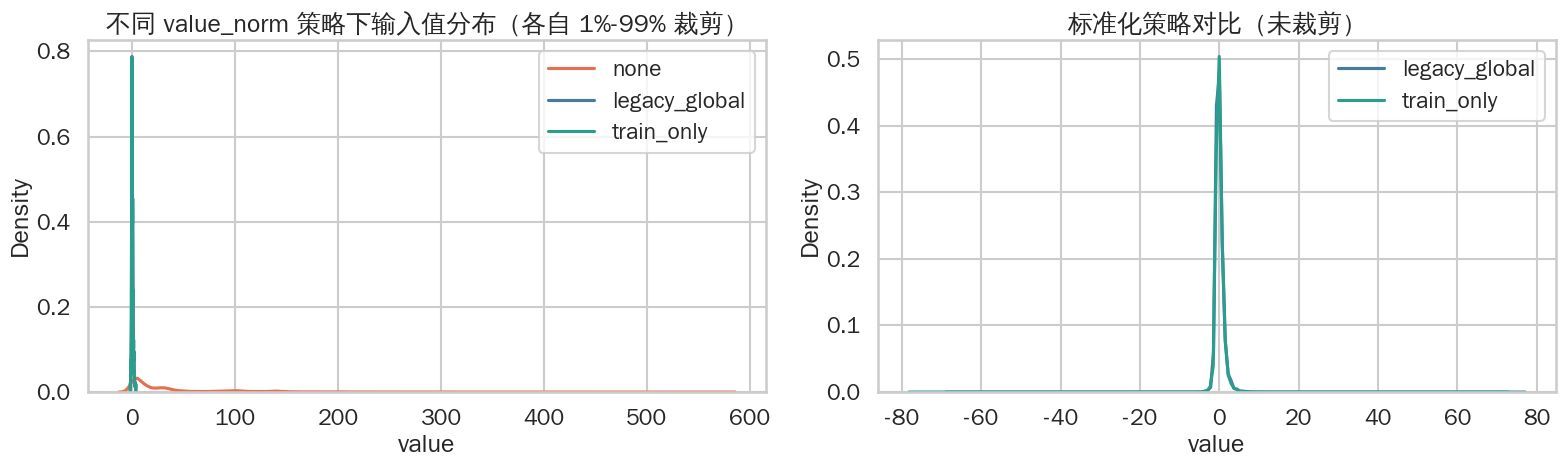

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

norm_value_cache = {mode: flat_values_by_norm(mode, split='train') for mode in ['none', 'legacy_global', 'train_only']}

# 左图：各策略各自裁剪到 [1%, 99%] 后比较，避免 none 把坐标轴拉爆
for mode, color in [('none', '#e76f51'), ('legacy_global', '#457b9d'), ('train_only', '#2a9d8f')]:
    v = norm_value_cache[mode]
    if len(v):
        lo, hi = np.quantile(v, [0.01, 0.99])
        v_clip = v[(v >= lo) & (v <= hi)]
        sns.kdeplot(v_clip, label=mode, color=color, fill=False, ax=axes[0])

axes[0].set_title('不同 value_norm 策略下输入值分布（各自 1%-99% 裁剪）')
axes[0].set_xlabel('value')
axes[0].set_ylabel('Density')
axes[0].legend()

# 右图：只看标准化后的两种策略，直接比较是否几乎重合
for mode, color in [('legacy_global', '#457b9d'), ('train_only', '#2a9d8f')]:
    v = norm_value_cache[mode]
    if len(v):
        sns.kdeplot(v, label=mode, color=color, fill=False, ax=axes[1])

axes[1].set_title('标准化策略对比（未裁剪）')
axes[1].set_xlabel('value')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()

norm_stats_df


## 14) 结论模板

你可以根据上面的图与统计，从以下角度总结：
1. 数据规模与稀疏程度：样本数、每样本观测数、时长分布
2. 不规则时间特征：时间间隔是否长尾、是否存在明显采样节律
3. 变量信息密度：哪些通道最稀疏、哪些最稳定
4. 变量联动关系：相关热图是否出现明显块状结构
5. 建模启发：是否适合 patch、插值、显式时间编码等策略